# NER Extractive Summarization

Model NER: `cahya/bert-base-indonesian-NER` (pre-trained BERT, tidak perlu training ulang)

## Cara kerja pipeline

```
Input Teks
    ↓
[cahya/bert-base-indonesian-NER]  ← download otomatis dari HuggingFace
    ↓ ekstrak entitas per kalimat (PER, ORG, LOC, LAW, CRD, ...)
Score tiap kalimat = jumlah entitas yang ditemukan
    ↓
Pilih top-3 kalimat dengan skor tertinggi
    ↓
Output: Ringkasan Ekstraktif
```

Noted: Tidak ada training

Model NER hanya dipakai untuk **memilih kalimat penting**, bukan menghasilkan teks baru.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Jalankan sekali per session (Colab sudah menyediakan torch dan pandas)
import subprocess, sys

_pkgs = ["transformers==4.40.0", "rouge-score", "sentencepiece"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + _pkgs, check=True)
print("Packages siap.")


Packages siap.


In [6]:
import os, re, time
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from pathlib import Path
import pandas as pd
import torch
from transformers import pipeline as hf_pipeline
from rouge_score import rouge_scorer as rouge_lib
from tqdm.auto import tqdm

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# ── Paths ────────────────────────────────────────────────────────────────────
# Google Colab: upload test.parquet ke Drive lalu sesuaikan DRIVE_ROOT di bawah
CWD  = Path.cwd()
ROOT = CWD if (CWD / "data").exists() else CWD.parent

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    # Sesuaikan path ini sesuai lokasi folder project di Google Drive kamu
    DRIVE_ROOT = Path("/content/drive/MyDrive/sovereign-dialect-bridge")
    if (DRIVE_ROOT / "data").exists():
        ROOT = DRIVE_ROOT
        print(f"  Drive terhubung: ROOT = {ROOT}")
    else:
        print(f"  Drive terhubung tapi '{DRIVE_ROOT}' tidak ditemukan — pakai path lokal")
except (ImportError, Exception):
    pass  # bukan Colab atau Drive tidak tersedia

DATA_DIR  = ROOT / "data"
NER_MODEL = "cahya/bert-base-indonesian-NER"
RANDOM_SEED = 42

print(f"Device   : {DEVICE}")
print(f"DATA_DIR : {DATA_DIR}  (exists={DATA_DIR.exists()})")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Drive terhubung: ROOT = /content/drive/MyDrive/sovereign-dialect-bridge
Device   : cpu
DATA_DIR : /content/drive/MyDrive/sovereign-dialect-bridge/data  (exists=True)


In [7]:
if not (DATA_DIR / "test.parquet").exists():
    raise FileNotFoundError(
        f"test.parquet tidak ditemukan di {DATA_DIR}.\n"
        "Upload file ke Google Drive dan sesuaikan DRIVE_ROOT di cell setup."
    )

# Evaluasi penuh: 700 sampel test set (tanpa subsetting)
df_test = pd.read_parquet(DATA_DIR / "test.parquet")

print(f"Sampel uji : {len(df_test)}")
print(f"Rata-rata panjang teks     : {df_test['text'].str.split().apply(len).mean():.0f} kata")
print(f"Rata-rata panjang ringkasan: {df_test['summary'].str.split().apply(len).mean():.0f} kata")
df_test[["text", "summary"]].head(2)


Sampel uji : 700
Rata-rata panjang teks     : 304 kata
Rata-rata panjang ringkasan: 60 kata


,text,summary
0,"Jakarta, CNN Indonesia - - Band asal AS, Sixpe...","Band asal AS, Sixpence None the Richer menjadi..."
1,"Zbigniew Brzezinski, penasihat keamanan nasion...","Zbigniew Brzezinski, penasihat keamanan nasion..."


In [8]:
# Load NER pipeline — di-cache otomatis di ~/.cache/huggingface/
# batch_size=32: mengirim 32 kalimat sekaligus ke GPU → jauh lebih cepat dari per-kalimat
_ner_device = 0 if DEVICE == "cuda" else ("mps" if DEVICE == "mps" else -1)

print(f"Memuat: {NER_MODEL}  (device={_ner_device})")
t0 = time.time()
try:
    ner_pipe = hf_pipeline(
        "ner",
        model=NER_MODEL,
        aggregation_strategy="simple",
        device=_ner_device,
        batch_size=32,
    )
except Exception as e:
    print(f"  {_ner_device} gagal ({e}), fallback CPU")
    ner_pipe = hf_pipeline(
        "ner",
        model=NER_MODEL,
        aggregation_strategy="simple",
        device=-1,
        batch_size=32,
    )
print(f"Loaded dalam {time.time()-t0:.1f}s")

# Verifikasi output model
_check = ner_pipe("Budi Karya dari Kementerian Perhubungan mengumumkan kebijakan di Jakarta.")
for e in _check:
    print(f"  {e['word']:25s} → {e['entity_group']}  (score={e['score']:.3f})")


Memuat: cahya/bert-base-indonesian-NER  (device=-1)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Some weights of the model checkpoint at cahya/bert-base-indonesian-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Loaded dalam 15.5s
  budi karya                → PER  (score=0.982)
  kementerian perhubungan   → NOR  (score=0.988)
  jakarta                   → GPE  (score=0.997)


In [9]:
def split_sentences(text: str) -> list:
    """Pisah kalimat dari teks asli (tanpa lowercase agar NER tetap akurat)."""
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s.strip()]


def summarize_ner(text: str, n_sentences: int = 3, max_words: int = 80) -> str:
    raw_sents = split_sentences(text)
    if len(raw_sents) <= n_sentences:
        return " ".join(" ".join(raw_sents).split()[:max_words])

    try:
        # Batched inference: list[str] → list[list[dict]]
        batch_ents = ner_pipe([s[:512] for s in raw_sents])
        scores = [len(e) for e in batch_ents]
    except Exception:
        # Fallback: per-kalimat jika batch gagal
        scores = []
        for s in raw_sents:
            try:
                scores.append(len(ner_pipe(s[:512])))
            except Exception:
                scores.append(0)

    ranked  = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:n_sentences]
    summary = " ".join(raw_sents[i] for i in sorted(ranked))
    return " ".join(summary.split()[:max_words])


print("Fungsi summarize_ner siap.")


Fungsi summarize_ner siap.


In [10]:
# Demo pada 1 sampel dari test set
_row = df_test.iloc[0]

print(f"TEKS ASLI ({len(_row['text'].split())} kata):")
print(f"  {_row['text'][:300]}")
print()
print(f"REFERENSI ({len(_row['summary'].split())} kata):")
print(f"  {_row['summary']}")
print()

t0  = time.time()
out = summarize_ner(_row["text"])
print(f"NER SUMMARY ({len(out.split())} kata, {time.time()-t0:.1f}s):")
print(f"  {out}")

TEKS ASLI (376 kata):
  Jakarta, CNN Indonesia - - Band asal AS, Sixpence None the Richer turut menjadi salah satu penampil yang begitu dinantikan dalam gelaran The 90 ’s Festival, Sabtu ( 25 / 11) malam, di Gambir Expo Kemayoran. Kehadiran mereka tak dipungkiri seolah untuk melengkapi kerinduan akan dendangan musik pada m

REFERENSI (69 kata):
  Band asal AS, Sixpence None the Richer menjadi salah satu penampil yang begitu dinantikan dalam gelaran The 90 ’s Festival, Sabtu ( 25 / 11) malam, di Gambir Expo Kemayoran. Kehadiran mereka seolah untuk melengkapi kerinduan akan dendangan musik pada masa ‘ 90 - an. Lagu ' Kiss Me ' salah satunya, hit andalan grup yang menandai kedatangan keduanya di Indonesia, boleh dibilang sangat populer di Indonesia hingga sekarang.

NER SUMMARY (80 kata, 4.0s):
  Jakarta, CNN Indonesia - - Band asal AS, Sixpence None the Richer turut menjadi salah satu penampil yang begitu dinantikan dalam gelaran The 90 ’s Festival, Sabtu ( 25 / 11) malam, di Gambir Expo

Mengevaluasi NER pada 700 sampel test...


Evaluating:   0%|          | 0/700 [00:00<?, ?sample/s]

Selesai dalam 1936.8s

Hasil NER BERT:
  rouge1  : 0.4959
  rouge2  : 0.3881
  rougeL  : 0.4469
  CR      : 0.2666

Hasil evaluasi pada test set (n=700):


,ROUGE-1,ROUGE-2,ROUGE-L,Comp. Ratio
Method,,,,
NER BERT,0.4778,0.3692,0.4262,0.2579
TextRank,0.6688,0.6003,0.6390,0.2250
NER heuristic,0.4272,0.3192,0.3788,0.2193


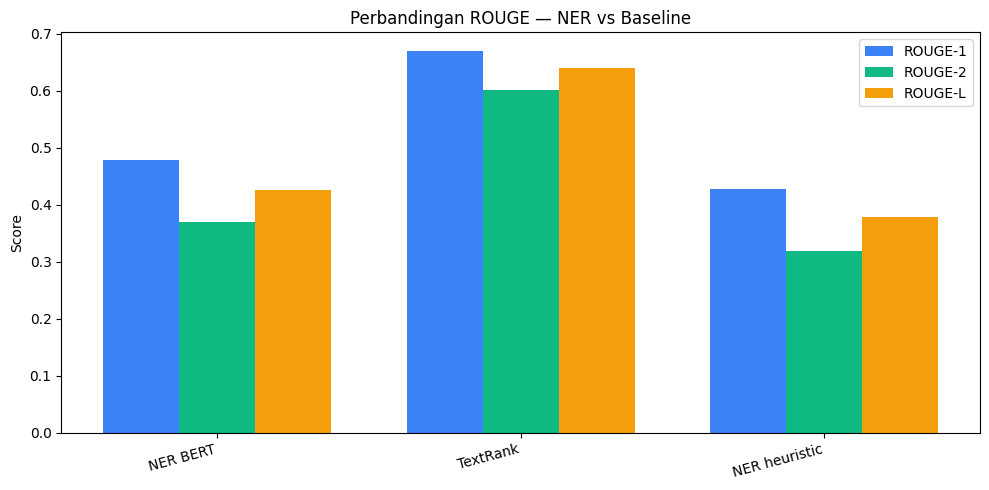

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def evaluate_extractive(fn, df):
    """Evaluasi fungsi ekstraktif pada seluruh df, return (metrics_dict, preds_list)."""
    scorer   = rouge_lib.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
    sums     = {"rouge1": 0.0, "rouge2": 0.0, "rougeL": 0.0}
    cr_total = 0.0
    preds    = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating", unit="sample"):
        pred = fn(row["text"])
        preds.append(pred)
        sc   = scorer.score(row["summary"], pred)
        for k in sums:
            sums[k] += sc[k].fmeasure
        cr_total += len(pred.split()) / max(len(row["text"].split()), 1)
    n = len(df)
    m = {k: round(v / n, 4) for k, v in sums.items()}
    m["CR"] = round(cr_total / n, 4)
    return m, preds


print(f"Mengevaluasi NER pada {len(df_test)} sampel test...")
t0 = time.time()
ner_metrics, preds = evaluate_extractive(summarize_ner, df_test)
print(f"Selesai dalam {time.time()-t0:.1f}s")
print(f"\nHasil NER BERT:")
for k, v in ner_metrics.items():
    print(f"  {k:8s}: {v}")

# Referensi dari training_sum.ipynb (n=700) — update jika sudah punya hasil baru
reference = {
    "TextRank"       : {"rouge1": 0.6688, "rouge2": 0.6003, "rougeL": 0.6390, "CR": 0.2250},
    "NER heuristic"  : {"rouge1": 0.4272, "rouge2": 0.3192, "rougeL": 0.3788, "CR": 0.2193},
    "NER BERT"       : {"rouge1": 0.4778, "rouge2": 0.3692, "rougeL": 0.4262, "CR": 0.2579},
}

results = {"NER BERT": ner_metrics}
results.update(reference)

results_df = pd.DataFrame(results).T.rename(columns={
    "rouge1": "ROUGE-1", "rouge2": "ROUGE-2", "rougeL": "ROUGE-L", "CR": "Comp. Ratio"
})
results_df.index.name = "Method"
print(f"\nHasil evaluasi pada test set (n={len(df_test)}):")
display(
    results_df.style
    .highlight_max(axis=0, color="lightgreen")
    .format("{:.4f}")
)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
methods = list(results.keys())
r1 = [results[m]["rouge1"] for m in methods]
r2 = [results[m]["rouge2"] for m in methods]
rl = [results[m]["rougeL"] for m in methods]

x = np.arange(len(methods))
w = 0.25
ax.bar(x - w, r1, w, label="ROUGE-1", color="#3b82f6")
ax.bar(x,     r2, w, label="ROUGE-2", color="#10b981")
ax.bar(x + w, rl, w, label="ROUGE-L", color="#f59e0b")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Perbandingan ROUGE — NER vs Baseline")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# Inspeksi manual: 3 sampel terbaik dan terburuk berdasarkan ROUGE-1
scorer = rouge_lib.RougeScorer(["rouge1"], use_stemmer=False)

df_result = df_test[["text", "summary"]].copy()
df_result["ner_pred"] = preds
df_result["rouge1"]   = [
    scorer.score(ref, pred)["rouge1"].fmeasure
    for ref, pred in zip(df_result["summary"], preds)
]

print("=== 3 TERBAIK ===")
for _, r in df_result.nlargest(3, "rouge1").iterrows():
    print(f"  ROUGE-1={r['rouge1']:.4f}")
    print(f"  REF : {r['summary'][:120]}")
    print(f"  PRED: {r['ner_pred'][:120]}")
    print()

print("=== 3 TERBURUK ===")
for _, r in df_result.nsmallest(3, "rouge1").iterrows():
    print(f"  ROUGE-1={r['rouge1']:.4f}")
    print(f"  REF : {r['summary'][:120]}")
    print(f"  PRED: {r['ner_pred'][:120]}")
    print()


=== 3 TERBAIK ===
  ROUGE-1=0.9496
  REF : Kecemerlangan pasangan ganda putri Greysia Polii / Apriyani Rahayu harus terhenti di partai final turnamen bulutangkis I
  PRED: Jakarta ( ANTARANews) - Kecemerlangan pasangan ganda putri Greysia Polii / Apriyani Rahayu harus terhenti di partai fina

  ROUGE-1=0.9375
  REF : Manajer Everton Sam Allardyce mengaku siap merelakan Ross Barkley pergi pada Januari nanti. Barkley yang di musim ini be
  PRED: Manajer Everton Sam Allardyce mengaku siap merelakan Ross Barkley pergi pada Januari nanti. Gelandang internasional Ingg

  ROUGE-1=0.9333
  REF : Sebuah wahana antariksa dua dimensi tengah disiapkan NASA untuk mengangkut sampah - sampah di luar angkasa dan mengembal
  PRED: Jakarta, CNN Indonesia - - Sebuah wahana antariksa dua dimensi tengah disiapkan NASA untuk mengangkut sampah - sampah di

=== 3 TERBURUK ===
  ROUGE-1=0.0820
  REF : China Academy of Launch Vehicle Technology yang berada di bawah naungan pemerintah setempat dilaporkan siap me